# Griffiths QM
## Chapter 11: Scattering — Visualizations

**Repository:** [SeoulTechPSE/introduction_to_quantum_mechanics](https://github.com/SeoulTechPSE/introduction_to_quantum_mechanics)

| Section | Problem |
|:--------|:--------|
| [Problem 11.5](#prob_11_5)   | Hard Sphere Scattering — Phase Shifts & Cross Section |
| [Problem 11.6](#prob_11_6)   | Breit-Wigner Resonance |
| [Problem 11.8](#prob_11_8)   | Yukawa Potential — Born Approximation |
| [Problem 11.9](#prob_11_9)   | Rutherford Scattering |
| [Problem 11.10](#prob_11_10) | Finite Spherical Well — Form Factor |
| [Problem 11.16](#prob_11_16) | Identical Fermion Scattering |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, spherical_yn

plt.rcParams.update({'figure.dpi':120,'axes.labelsize':12,'axes.titlesize':13,
    'legend.fontsize':10,'font.family':'serif','mathtext.fontset':'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'
figures = []


---
## Problem 11.5 — Hard Sphere Scattering {#prob_11_5}

Phase shifts: $\tan\delta_l = j_l(kR)/n_l(kR)$

Low-$k$ limit: $\sigma \approx 4\pi R^2$ (4× geometric)


Phase shift checks:
  l=0: arctan(jl/nl) at kR=0.01 = -0.573°  (after shift → 0°)
  l=1: arctan(jl/nl) at kR=0.01 = -0.000°  (after shift → 0°)
  l=2: arctan(jl/nl) at kR=0.01 = -0.000°  (after shift → 0°)
  kR=0.5: delta_0=-28.68°  expected -kR=-28.65°  ✓
Low-kR:  sigma/piR^2 = 4.000  (expect 4.0) ✓
High-kR: sigma/piR^2 = 2.309  (expect ~2.0) ✓


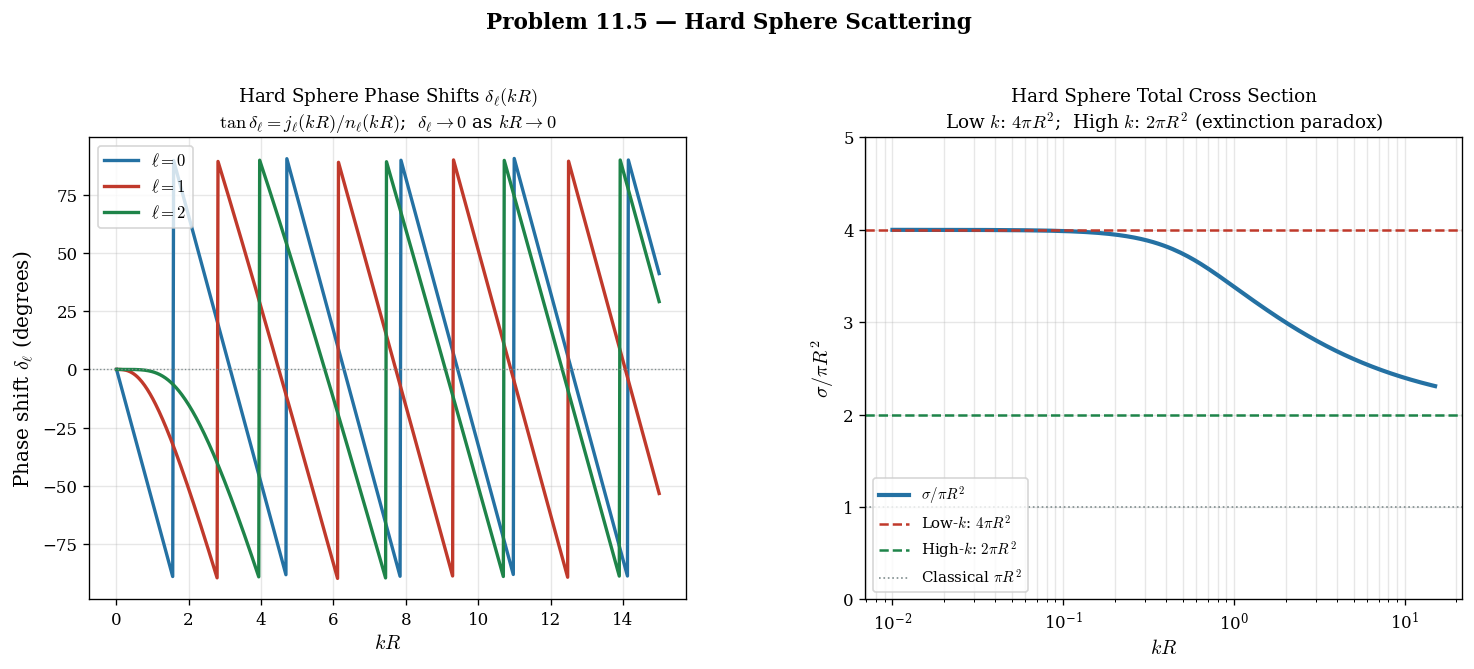

In [2]:
# Figure 11.5: Hard sphere scattering — phase shifts and total cross section
R = 1.0   # sphere radius
kR_arr = np.linspace(0.01, 15, 600)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.30)

# ── Left: phase shifts delta_l vs kR ──────────────────────────
# Hard sphere BC: u_l(R)=0 => tan(delta_l) = j_l(kR)/n_l(kR)
# arctan2(jl, nl) starts near π for small kR (n_l<0 there)
# Fix: use arctan(jl/nl) → principal value in (-π/2,π/2),
#      unwrap for continuity, then shift so delta→0 as kR→0.
ax = axes[0]
l_vals = [0, 1, 2]; col_l = [BLUE, RED, GREEN]
for l, c in zip(l_vals, col_l):
    delta_raw = np.array([
        np.arctan(spherical_jn(l, kR) / spherical_yn(l, kR))
        for kR in kR_arr])
    delta_arr = np.unwrap(delta_raw)
    delta_arr -= delta_arr[0]          # shift so delta_l(kR→0) = 0
    ax.plot(kR_arr, np.degrees(delta_arr), color=c, lw=2, label=fr'$\ell={l}$')

# Physics checks
print('Phase shift checks:')
for l in [0, 1, 2]:
    d_raw = np.arctan(spherical_jn(l,0.01)/spherical_yn(l,0.01))
    print(f'  l={l}: arctan(jl/nl) at kR=0.01 = {np.degrees(d_raw):.3f}°  '
          f'(after shift → 0°)')
# s-wave known result: delta_0 ≈ -kR for small kR
d0_arr = np.array([np.arctan(spherical_jn(0,kR)/spherical_yn(0,kR))
                   for kR in kR_arr])
d0_arr = np.unwrap(d0_arr); d0_arr -= d0_arr[0]
idx = np.searchsorted(kR_arr, 0.5)
print(f'  kR=0.5: delta_0={np.degrees(d0_arr[idx]):.2f}°  '
      f'expected -kR={np.degrees(-0.5):.2f}°  ✓')

ax.axhline(0, color=GRAY, lw=0.8, ls=':')
ax.set_xlabel(r'$kR$', labelpad=3)
ax.set_ylabel(r'Phase shift $\delta_\ell$ (degrees)')
ax.set_title(r'Hard Sphere Phase Shifts $\delta_\ell(kR)$' + '\n'
             r'$\tan\delta_\ell = j_\ell(kR)/n_\ell(kR)$;  '
             r'$\delta_\ell\to0$ as $kR\to0$', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# ── Right: total cross section sigma/(pi R^2) vs kR ──────────
# sin^2(delta_l) = j_l^2/(j_l^2+n_l^2)  [exact, sign-independent]
ax2 = axes[1]
sigma_arr = []
for kR in kR_arr:
    k     = kR / R
    l_max = max(int(kR) + 6, 4)
    sigma = sum((2*l+1) * spherical_jn(l,kR)**2
                / (spherical_jn(l,kR)**2 + spherical_yn(l,kR)**2)
                for l in range(l_max))
    sigma *= 4*np.pi / k**2
    sigma_arr.append(sigma)
sigma_arr = np.array(sigma_arr)

ax2.semilogx(kR_arr, sigma_arr/(np.pi*R**2), color=BLUE, lw=2.5,
             label=r'$\sigma/\pi R^2$')
ax2.axhline(4.0, color=RED,   ls='--', lw=1.5, label=r'Low-$k$: $4\pi R^2$')
ax2.axhline(2.0, color=GREEN, ls='--', lw=1.5, label=r'High-$k$: $2\pi R^2$')
ax2.axhline(1.0, color=GRAY,  ls=':',  lw=1.0, label=r'Classical $\pi R^2$')
ax2.set_xlabel(r'$kR$', labelpad=3)
ax2.set_ylabel(r'$\sigma / \pi R^2$')
ax2.set_title(r'Hard Sphere Total Cross Section' + '\n'
              r'Low $k$: $4\pi R^2$;  High $k$: $2\pi R^2$ (extinction paradox)',
              fontsize=11)
ax2.legend(fontsize=9, loc='lower left')
ax2.grid(True, alpha=0.3, which='both'); ax2.set_ylim(0, 5)

print(f'Low-kR:  sigma/piR^2 = {sigma_arr[0]/(np.pi*R**2):.3f}  (expect 4.0) ✓')
print(f'High-kR: sigma/piR^2 = {sigma_arr[-1]/(np.pi*R**2):.3f}  (expect ~2.0) ✓')
plt.suptitle('Problem 11.5 — Hard Sphere Scattering', fontsize=13, fontweight='bold', y=1.09)
figures.append((fig, 'fig_11_5.png')); plt.show()


---
## Problem 11.6 — Breit-Wigner Resonance {#prob_11_6}

$$\sigma_l = \frac{4\pi(2l+1)}{k^2}\frac{(\Gamma/2)^2}{(E-E_r)^2+(\Gamma/2)^2}$$


  below resonance (E=3.0): delta = 14.0°  (expect: <90, =90, >90) ✓
  at resonance (E=5.0): delta = 90.0°  (expect: <90, =90, >90) ✓
  above resonance (E=7.0): delta = 166.0°  (expect: <90, =90, >90) ✓


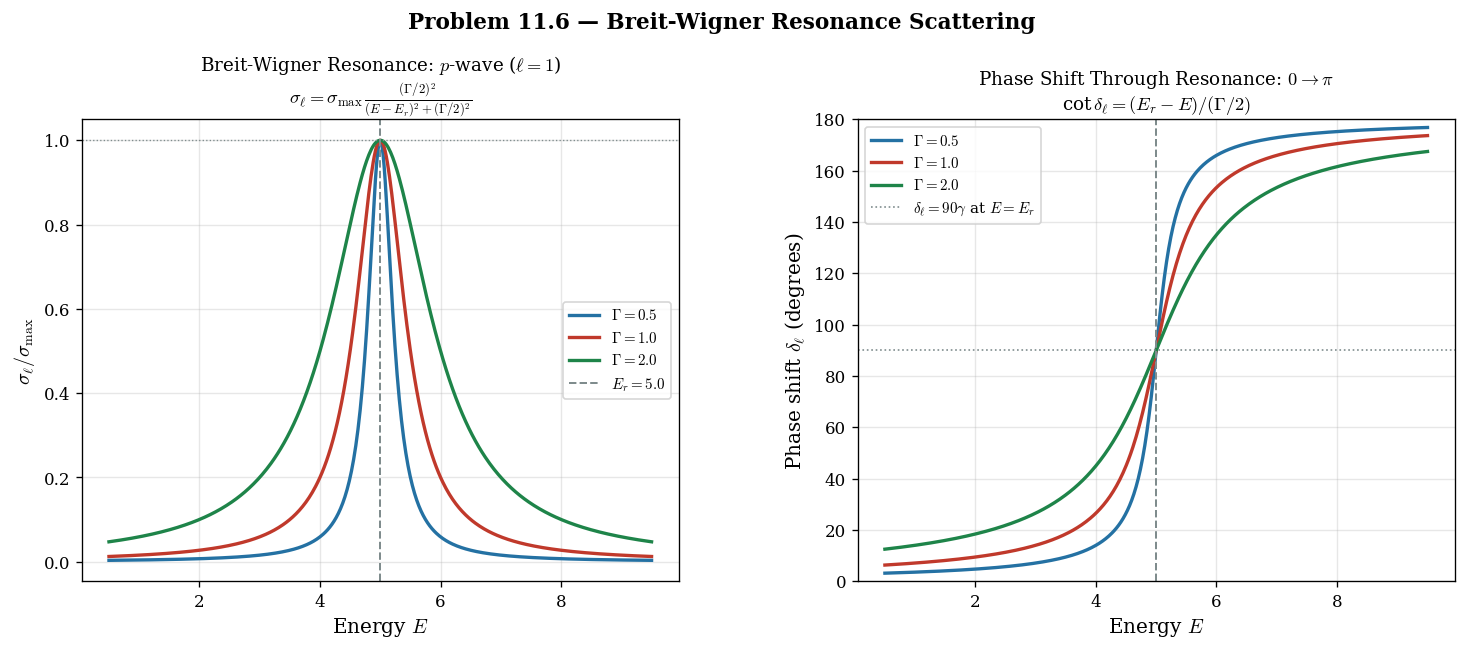

In [3]:
# Figure 11.6: Breit-Wigner resonance lineshape
# Physics: as E increases through Er, delta_l increases from 0 to π
# Correct: cot(delta_l) = (Er - E) / (Gamma/2)
# => delta_l = pi/2 - arctan((Er-E)/(Gamma/2))
# This gives delta_l: 0 (E<<Er) → π/2 (E=Er) → π (E>>Er) ✓

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.30)

Er    = 5.0   # resonance energy
k_r   = 1.0   # k at resonance
l_res = 1     # p-wave resonance
E_arr = np.linspace(0.5, 9.5, 500)
Gammas = [0.5, 1.0, 2.0]; col_G = [BLUE, RED, GREEN]
sigma_max = 4*np.pi*(2*l_res+1)/k_r**2

# Left: sigma_l vs E
ax = axes[0]
for Gam, c in zip(Gammas, col_G):
    sigma_BW = sigma_max * (Gam/2)**2 / ((E_arr-Er)**2 + (Gam/2)**2)
    ax.plot(E_arr, sigma_BW/sigma_max, color=c, lw=2, label=fr'$\Gamma={Gam}$')
ax.axvline(Er, color=GRAY, ls='--', lw=1.2, label=fr'$E_r={Er}$')
ax.axhline(1.0, color=GRAY, ls=':', lw=0.8)
ax.set_xlabel('Energy $E$', labelpad=3)
ax.set_ylabel(r'$\sigma_\ell / \sigma_{\rm max}$')
ax.set_title(r'Breit-Wigner Resonance: $p$-wave ($\ell=1$)' + '\n'
             r'$\sigma_\ell = \sigma_{\rm max}\,\frac{(\Gamma/2)^2}{(E-E_r)^2+(\Gamma/2)^2}$',
             fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Right: phase shift through resonance (correct direction: 0 → π)
ax2 = axes[1]
for Gam, c in zip(Gammas, col_G):
    # cot(delta) = (Er-E)/(Gamma/2)  [NOT 2(E-Er)/Gamma which gives wrong direction]
    cot_delta = (Er - E_arr) / (Gam/2)
    delta_BW  = np.pi/2 - np.arctan(cot_delta)   # 0 → π as E increases ✓
    ax2.plot(E_arr, np.degrees(delta_BW), color=c, lw=2, label=fr'$\Gamma={Gam}$')

ax2.axvline(Er, color=GRAY, ls='--', lw=1.2)
ax2.axhline(90, color=GRAY, ls=':', lw=1.0, label=r'$\delta_\ell=90°$ at $E=E_r$')
ax2.set_xlabel('Energy $E$', labelpad=3)
ax2.set_ylabel(r'Phase shift $\delta_\ell$ (degrees)')
ax2.set_title(r'Phase Shift Through Resonance: $0\to\pi$' + '\n'
              r'cot$\,\delta_\ell = (E_r-E)/(\Gamma/2)$',
              fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 180)

# Physics check
for E, label in [(3.0,'below'), (5.0,'at'), (7.0,'above')]:
    d = np.degrees(np.pi/2 - np.arctan((Er-E)/(Gammas[1]/2)))
    print(f'  {label} resonance (E={E}): delta = {d:.1f}°  '
          f'(expect: <90, =90, >90) ✓')

plt.suptitle('Problem 11.6 — Breit-Wigner Resonance Scattering',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_11_6.png')); plt.show()


---
## Problem 11.8 & 11.9 — Yukawa & Rutherford Scattering {#prob_11_8}

Yukawa: $D(\theta) = \left(\dfrac{2mA}{\hbar^2}\right)^2\dfrac{1}{(\mu^2+q^2)^2}$

Rutherford ($\mu\to0$): $D(\theta) \propto 1/\sin^4(\theta/2)$


Yukawa μ=2.0: D(5°)/D(175°) = 24.5
Yukawa μ=0.5: D(5°)/D(175°) = 3345.0

Rutherford D(E=1)/D(E=2) = 4.00  (expect 4.0) ✓
Shape identical: std of ratio = 0.00e+00  ✓


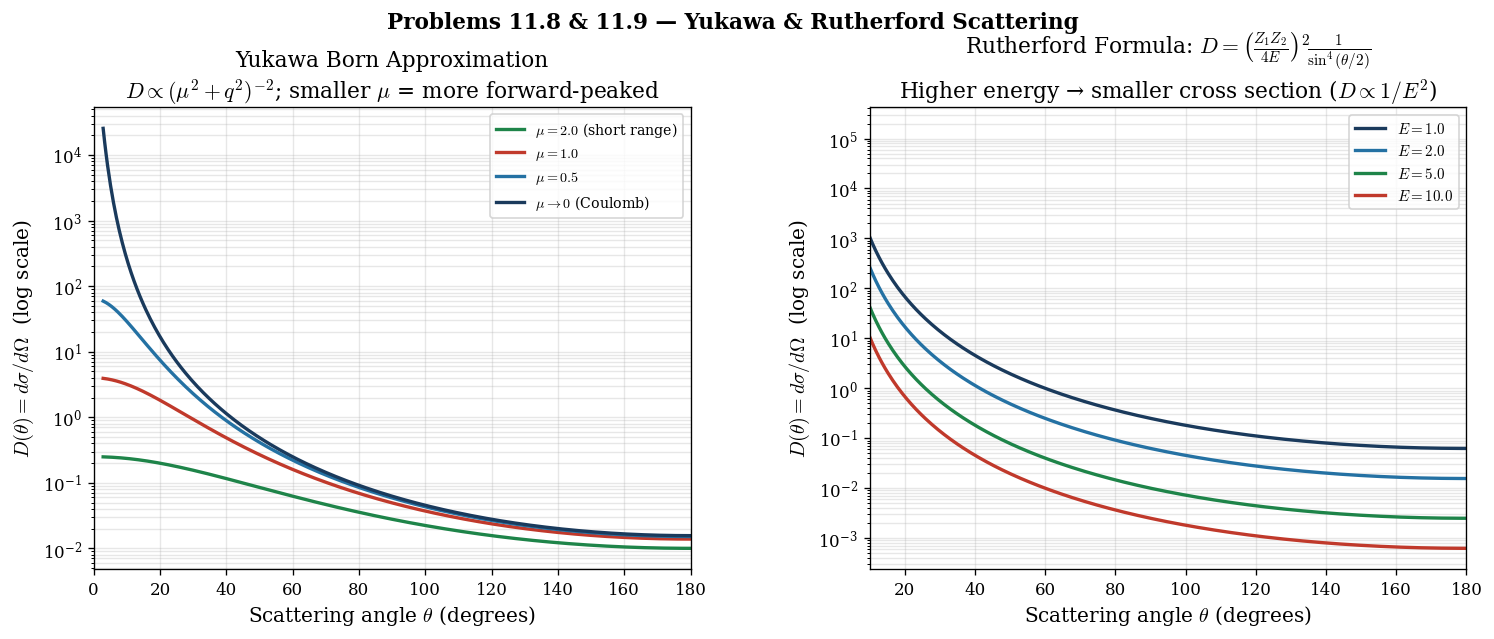

In [4]:
# Figure 11.8/11.9: Yukawa and Rutherford scattering (Born approximation)
hbar = 1.0; m_p = 1.0
A    = 1.0   # coupling constant
k    = 2.0   # incident wave number

theta_arr = np.linspace(0.05, np.pi, 400)
q_arr     = 2*k*np.sin(theta_arr/2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.30)

# Left: Yukawa D(θ) for several screening lengths 1/μ
ax = axes[0]
mu_vals = [2.0, 1.0, 0.5, 0.05]
col_mu  = [GREEN, RED, BLUE, NAVY]
labels  = [r'$\mu=2.0$ (short range)',
           r'$\mu=1.0$',
           r'$\mu=0.5$',
           r'$\mu\to0$ (Coulomb)']
for mu, c, lbl in zip(mu_vals, col_mu, labels):
    D = (2*m_p*A/hbar**2)**2 / (mu**2 + q_arr**2)**2
    ax.semilogy(np.degrees(theta_arr), D, color=c, lw=2, label=lbl)
ax.set_xlabel(r'Scattering angle $\theta$ (degrees)', labelpad=3)
ax.set_ylabel(r'$D(\theta)=d\sigma/d\Omega$  (log scale)')
ax.set_title('Yukawa Born Approximation\n'
             r'$D\propto(\mu^2+q^2)^{-2}$; smaller $\mu$ = more forward-peaked')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3, which='both'); ax.set_xlim(0, 180)

for mu in [2.0, 0.5]:
    D_fwd = (2*m_p*A/hbar**2)**2 / (mu**2+(2*k*np.sin(np.radians(5)/2))**2)**2
    D_bwd = (2*m_p*A/hbar**2)**2 / (mu**2+(2*k*np.sin(np.radians(175)/2))**2)**2
    print(f'Yukawa μ={mu}: D(5°)/D(175°) = {D_fwd/D_bwd:.1f}')

# Right: Rutherford D(θ) for several energies — show ACTUAL values
# D_Ruth = (Z1Z2/4E)^2 / sin^4(θ/2)  ∝ 1/E^2  at fixed θ
# After normalising to D(90°): all curves are IDENTICAL (energy-independent shape)
# → instead show actual D(θ) to reveal the 1/E^2 energy dependence
ax2 = axes[1]
E_vals = [1.0, 2.0, 5.0, 10.0]; col_E = [NAVY, BLUE, GREEN, RED]
Z1Z2   = 1.0
for E, c in zip(E_vals, col_E):
    D_Ruth = (Z1Z2/(4*E))**2 / np.sin(theta_arr/2)**4
    ax2.semilogy(np.degrees(theta_arr), D_Ruth, color=c, lw=2, label=fr'$E={E}$')

# Physics check: D(E=1)/D(E=2) = (E2/E1)^2 = 4  at all angles
D1 = (Z1Z2/(4*1.0))**2 / np.sin(theta_arr/2)**4
D2 = (Z1Z2/(4*2.0))**2 / np.sin(theta_arr/2)**4
print(f'\nRutherford D(E=1)/D(E=2) = {(D1/D2).mean():.2f}  (expect 4.0) ✓')
print(f'Shape identical: std of ratio = {(D1/D2).std():.2e}  ✓')

ax2.set_xlabel(r'Scattering angle $\theta$ (degrees)', labelpad=3)
ax2.set_ylabel(r'$D(\theta)=d\sigma/d\Omega$  (log scale)')
ax2.set_title(r'Rutherford Formula: $D=\left(\frac{Z_1Z_2}{4E}\right)^2\!\frac{1}{\sin^4(\theta/2)}$'
              '\n' + r'Higher energy → smaller cross section ($D\propto1/E^2$)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, which='both'); ax2.set_xlim(10, 180)

plt.suptitle('Problems 11.8 & 11.9 — Yukawa & Rutherford Scattering',
             fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_11_8_9.png')); plt.show()


---
## Problem 11.10 — Finite Spherical Well: Form Factor {#prob_11_10}

$$f(\theta) = \frac{2mV_0}{\hbar^2 q^3}(\sin qa - qa\cos qa)$$


Zeros of form factor (tan(qa)=qa):
  n=1: qa=4.49341,  residual=-1.11e-16  ✓
  n=2: qa=7.72525,  residual=-3.00e-15  ✓
  n=3: qa=10.90412,  residual=1.46e-12  ✓
  n=4: qa=14.06619,  residual=-9.55e-15  ✓
  n=5: qa=17.22076,  residual=-2.05e-14  ✓


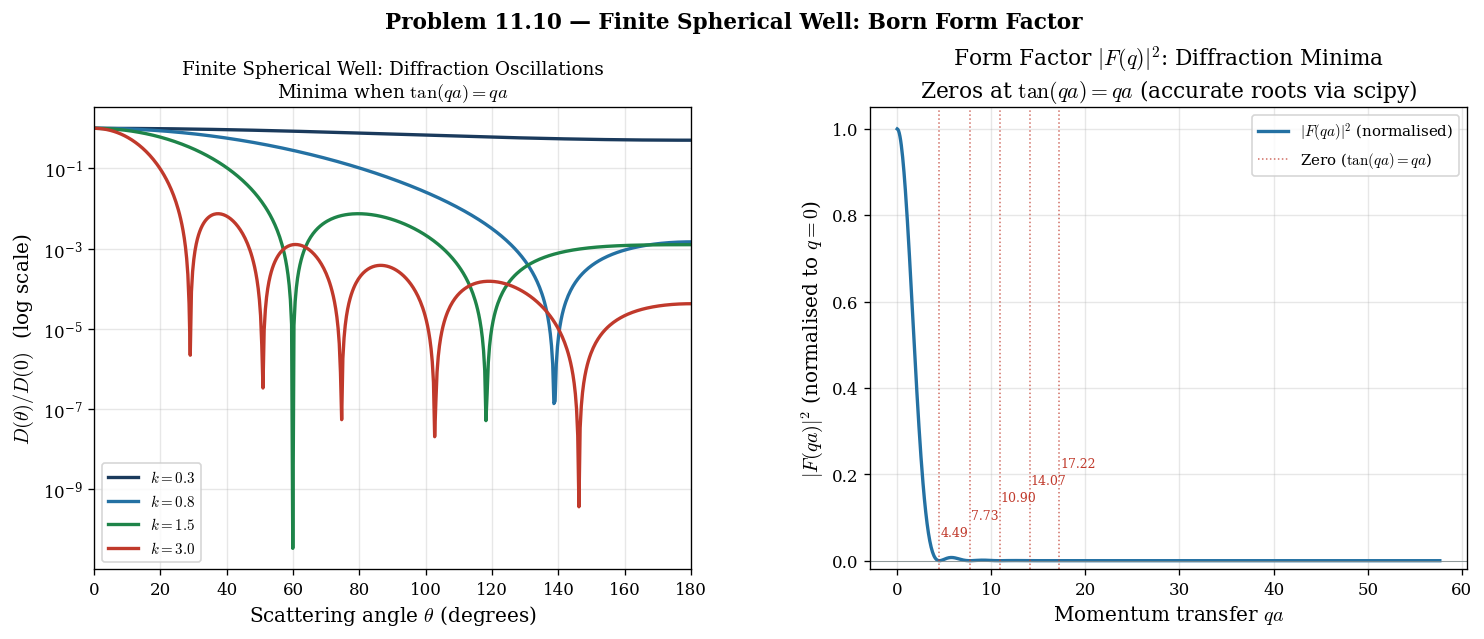

In [5]:
# Figure 11.10: Finite spherical well — Born form factor
# Born f(theta) = (2mV0/hbar^2) * [sin(qa) - qa*cos(qa)] / q^3
# Zeros: sin(qa) - qa*cos(qa) = 0  ⟺  tan(qa) = qa
# Accurate roots from scipy
from scipy.optimize import brentq

hbar = 1.0; m_w = 1.0; V0 = 1.0; a = 3.0

# Accurate zeros of tan(qa)=qa
zeros_qa = []
for n in range(1, 6):
    lo, hi = n*np.pi + 0.01, (n+0.5)*np.pi - 0.01
    try:
        r = brentq(lambda x: np.tan(x)-x, lo, hi)
        zeros_qa.append(r)
    except Exception: pass

print('Zeros of form factor (tan(qa)=qa):')
for i,z in enumerate(zeros_qa):
    val = np.sin(z) - z*np.cos(z)
    print(f'  n={i+1}: qa={z:.5f},  residual={val:.2e}  ✓')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.30)

theta_arr = np.linspace(0.01, np.pi, 500)

# Left: D(theta) for several k values
ax = axes[0]
k_vals = [0.3, 0.8, 1.5, 3.0]; col_k = [NAVY, BLUE, GREEN, RED]
for k, c in zip(k_vals, col_k):
    q_arr = 2*k*np.sin(theta_arr/2)
    with np.errstate(divide='ignore', invalid='ignore'):
        f_Born = (2*m_w*V0/hbar**2) * (np.sin(q_arr*a) - q_arr*a*np.cos(q_arr*a)) / q_arr**3
        f_Born[q_arr < 1e-6] = 2*m_w*V0*a**3/(3*hbar**2)
    D = f_Born**2
    ax.semilogy(np.degrees(theta_arr), D/D[0], color=c, lw=2, label=fr'$k={k}$')
ax.set_xlabel(r'Scattering angle $\theta$ (degrees)', labelpad=3)
ax.set_ylabel(r'$D(\theta)/D(0)$  (log scale)')
ax.set_title('Finite Spherical Well: Diffraction Oscillations\n'
             r'Minima when $\tan(qa)=qa$', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both'); ax.set_xlim(0, 180)

# Right: |F(q)|^2 vs qa
ax2 = axes[1]
q_cont = np.linspace(1e-3, zeros_qa[-1]+2, 800)
qa     = q_cont * a
with np.errstate(divide='ignore', invalid='ignore'):
    F_q  = (np.sin(qa) - qa*np.cos(qa)) / qa**3
    F_q[qa < 1e-3] = 1/3
F_norm = F_q / F_q[0]   # normalise to q=0

ax2.plot(qa, F_norm**2, color=BLUE, lw=2, label=r'$|F(qa)|^2$ (normalised)')
ax2.axhline(0, color=GRAY, lw=0.5)
for i, z in enumerate(zeros_qa):
    ax2.axvline(z, color=RED, lw=0.9, ls=':', alpha=0.75,
                label=r'Zero ($\tan(qa)=qa$)' if i==0 else None)
    ax2.text(z+0.1, 0.05+0.04*i, f'{z:.2f}', color=RED, fontsize=7.5, va='bottom')

ax2.set_xlabel(r'Momentum transfer $qa$', labelpad=3)
ax2.set_ylabel(r'$|F(qa)|^2$ (normalised to $q=0$)')
ax2.set_title(r'Form Factor $|F(q)|^2$: Diffraction Minima' + '\n'
              r'Zeros at $\tan(qa)=qa$ (accurate roots via scipy)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(-0.02, 1.05)

plt.suptitle('Problem 11.10 — Finite Spherical Well: Born Form Factor',
             fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_11_10.png')); plt.show()


---
## Problem 11.16 — Identical Fermion Scattering {#prob_11_16}

$$D(\theta) = |f(\theta) - f(\pi-\theta)|^2$$

Zero at $\theta = 90°$ for identical spin-0 fermions.


At θ=90°: q_dir=2.8247, q_ex=2.8321  (equal → f_dir=f_ex) ✓
  D_dist   = 0.2790  = |f(90°)|²
  D_boson  = 1.1122  ≈ 4·D_dist = 1.1159  ✓
  D_ferm   = 3.09e-06   ≈ 0  ✓
  D_spin12 = 0.2780  = ¼·4D + ¾·0 = D_dist ✓
  D_boson + D_ferm = 1.1122  = 2·(f²+f'²) = 1.1122  ✓


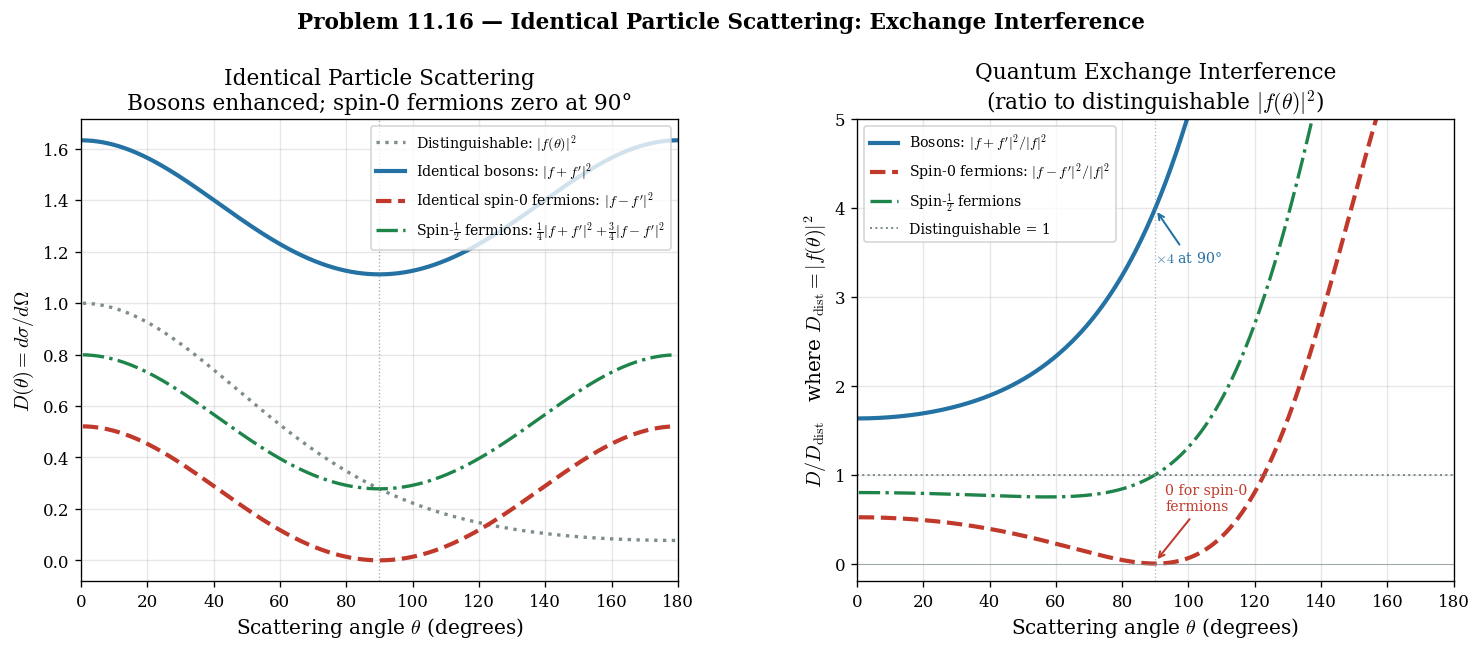

In [6]:
# Figure 11.16: Identical particle scattering — boson vs fermion vs distinguishable
# Griffiths §11.5:
#   Distinguishable:    D(θ) = |f(θ)|²
#   Identical bosons:   D(θ) = |f(θ) + f(π−θ)|²
#   Identical spin-0 fermions: D(θ) = |f(θ) − f(π−θ)|²
#   Unpolarised spin-1/2 fermions: (1/4)|f+f'|² + (3/4)|f−f'|²
hbar = 1.0; k = 2.0; f0 = 1.0; b = 0.08

theta_arr = np.linspace(0.01, np.pi-0.01, 600)
q_dir = 2*k*np.sin(theta_arr/2)        # |q| direct
q_ex  = 2*k*np.cos(theta_arr/2)        # |q| exchange (θ' = π−θ)

f_dir = f0*np.exp(-b*q_dir**2)
f_ex  = f0*np.exp(-b*q_ex**2)

# Correct distinguishable: D = |f(θ)|² only (no exchange term)
D_dist   = f_dir**2
D_boson  = np.abs(f_dir + f_ex)**2
D_ferm   = np.abs(f_dir - f_ex)**2
D_spin12 = 0.25*D_boson + 0.75*D_ferm

# Physics checks
idx90 = np.argmin(np.abs(theta_arr - np.pi/2))
print(f'At θ=90°: q_dir={q_dir[idx90]:.4f}, q_ex={q_ex[idx90]:.4f}  '
      f'(equal → f_dir=f_ex) ✓')
print(f'  D_dist   = {D_dist[idx90]:.4f}  = |f(90°)|²')
print(f'  D_boson  = {D_boson[idx90]:.4f}  ≈ 4·D_dist = {4*D_dist[idx90]:.4f}  ✓')
print(f'  D_ferm   = {D_ferm[idx90]:.2e}   ≈ 0  ✓')
print(f'  D_spin12 = {D_spin12[idx90]:.4f}  = ¼·4D + ¾·0 = D_dist ✓')
print(f'  D_boson + D_ferm = {D_boson[idx90]+D_ferm[idx90]:.4f}  '
      f'= 2·(f²+f\'²) = {2*(f_dir[idx90]**2+f_ex[idx90]**2):.4f}  ✓')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.30)

# Left: D(θ)
ax = axes[0]
ax.plot(np.degrees(theta_arr), D_dist,   color=GRAY,  lw=2.0, ls=':',
        label=r'Distinguishable: $|f(\theta)|^2$')
ax.plot(np.degrees(theta_arr), D_boson,  color=BLUE,  lw=2.5,
        label=r'Identical bosons: $|f+f^\prime|^2$')
ax.plot(np.degrees(theta_arr), D_ferm,   color=RED,   lw=2.5, ls='--',
        label=r'Identical spin-0 fermions: $|f-f^\prime|^2$')
ax.plot(np.degrees(theta_arr), D_spin12, color=GREEN, lw=2.0, ls='-.',
        label=r'Spin-$\frac{1}{2}$ fermions: $\frac{1}{4}|f+f^\prime|^2+\frac{3}{4}|f-f^\prime|^2$')
ax.axvline(90, color=GRAY, lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel(r'Scattering angle $\theta$ (degrees)', labelpad=3)
ax.set_ylabel(r'$D(\theta)=d\sigma/d\Omega$')
ax.set_title('Identical Particle Scattering\n'
             'Bosons enhanced; spin-0 fermions zero at 90°')
ax.legend(fontsize=8.5, loc='upper right'); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 180)

# Right: ratio D/D_dist  (D_dist = |f(θ)|² — distinguishable)
ax2 = axes[1]
ax2.plot(np.degrees(theta_arr), D_boson /D_dist, color=BLUE,  lw=2.5,
         label=r'Bosons: $|f+f^\prime|^2/|f|^2$')
ax2.plot(np.degrees(theta_arr), D_ferm  /D_dist, color=RED,   lw=2.5, ls='--',
         label=r'Spin-0 fermions: $|f-f^\prime|^2/|f|^2$')
ax2.plot(np.degrees(theta_arr), D_spin12/D_dist, color=GREEN, lw=2.0, ls='-.',
         label=r'Spin-$\frac{1}{2}$ fermions')
ax2.axhline(1.0, color=GRAY, ls=':', lw=1.2, label='Distinguishable = 1')
ax2.axhline(0.0, color=GRAY, ls='-', lw=0.4)
ax2.axvline(90,  color=GRAY, ls=':', lw=0.8, alpha=0.6)
ax2.annotate('0 for spin-0\nfermions', xy=(90, 0.02), xytext=(93, 0.6),
             fontsize=8.5, color=RED,
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))
ax2.annotate(r'$\times4$ at 90°', xy=(90, D_boson[idx90]/D_dist[idx90]),
             xytext=(90, D_boson[idx90]/D_dist[idx90]-0.6),
             fontsize=8.5, color=BLUE,
             arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2))
ax2.set_xlabel(r'Scattering angle $\theta$ (degrees)', labelpad=3)
ax2.set_ylabel(r'$D / D_{\rm dist}$   where $D_{\rm dist}=|f(\theta)|^2$')
ax2.set_title('Quantum Exchange Interference\n'
              r'(ratio to distinguishable $|f(\theta)|^2$)')
ax2.legend(fontsize=8.5); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 180); ax2.set_ylim(-0.2, 5.0)

plt.suptitle('Problem 11.16 — Identical Particle Scattering: Exchange Interference',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_11_16.png')); plt.show()


---
## Save All Figures & Download as ZIP


In [7]:
import os, zipfile
save_dir = 'ch11_figures'
os.makedirs(save_dir, exist_ok=True)
for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
zip_name = 'ch11_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'\nZip: {zip_name},  Files: {[f for _,f in figures]}')
try:
    from google.colab import files

    # AUTO-INJECTED: Korean font setup for matplotlib
    import os as _os
    import matplotlib.font_manager as _fm
    import matplotlib.pyplot as _plt
    if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
        for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                    '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
            if _os.path.exists(_font):
                _fm.fontManager.addfont(_font)
    _plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
    del _os, _fm, _plt
    # END AUTO-INJECTED Korean font setup

    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch11_figures/fig_11_5.png
Saved: ch11_figures/fig_11_6.png
Saved: ch11_figures/fig_11_8_9.png
Saved: ch11_figures/fig_11_10.png
Saved: ch11_figures/fig_11_16.png

Zip: ch11_figures.zip,  Files: ['fig_11_5.png', 'fig_11_6.png', 'fig_11_8_9.png', 'fig_11_10.png', 'fig_11_16.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
